# Urban seismic denoising: one problem, two toolkits

Small earthquakes under a city are buried in traffic noise. This notebook scores
denoising methods from **geophysics** (bandpass filters, wavelets, stacking) and from
**quantitative finance** (random-matrix cleaning, minimum-variance weighting) on the
things a seismologist needs: the arrival time, and which way the ground moved first.

- **Part A** - 3,000 real noisy traces from the Southern California Seismic Network
- **Part B** - a synthetic array, where the truth is known exactly

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, '..')
import figstyle
figstyle.apply()
import seismic as s

## Part A - real traces

Small (M ≤ 3.5), local (≤ 50 km) earthquakes on the CI network, with an analyst-labelled
first motion, from the noisiest fifth of the dataset. Each trace is 6 s at 100 Hz with the
P arrival at its centre.

**Calibration first.** The picker (STA/LTA, threshold 6) and the first-motion estimator
were tuned on the *quietest* traces, where they should be near perfect:

In [2]:
Xq, Yq, *_ = s.load_scsn(n=2000, snr_quantile=(0.8, 1.0), seed=1)
eq = s.pick_error_seconds(s.sta_lta_pick(Xq))
print(f"quiet traces: picked within 0.2 s {np.mean(np.abs(eq) <= 0.2):.0%}, "
      f"first motion agrees with analysts {np.mean(s.first_motion(Xq) == Yq):.0%}")

X, Y, snr, mag, dist = s.load_scsn(n=3000, snr_quantile=(0.0, 0.2), seed=0)
print(f"noisy set: {len(X)} traces, median SNR {np.median(snr):.1f}")

quiet traces: picked within 0.2 s 99%, first motion agrees with analysts 97%


noisy set: 3000 traces, median SNR 2.7


### The honest test: move the arrival

Every trace in the file has its arrival at sample 300. A method that learns from many
traces at once can learn "something happens at 300" and paint it in. So every method is
scored twice: on the traces as they come, and on a random 4.5 s window of each, which
puts the arrival anywhere from 1.5 to 3 s.

In [3]:
X_shift, arrivals = s.random_shift(X, seed=0)
centred = s.scoreboard(X, Y)
shifted = s.scoreboard(X_shift, Y, arrivals)

table = pd.DataFrame({
    'picks right, arrival fixed': {k: v['picked_within_tolerance'] for k, v in centred.items()},
    'picks right, arrival moved': {k: v['picked_within_tolerance'] for k, v in shifted.items()},
    'first motion kept': {k: v['polarity_correct'] for k, v in shifted.items()},
    'SNR gain (dB), arrival fixed': {k: v['snr_gain_db'] for k, v in centred.items()},
    'SNR gain (dB), arrival moved': {k: v['snr_gain_db'] for k, v in shifted.items()},
})
table.round(2)

,"picks right, arrival fixed","picks right, arrival moved",first motion kept,"SNR gain (dB), arrival fixed","SNR gain (dB), arrival moved"
raw,0.55,0.56,0.91,0.00,0.00
bandpass,0.63,0.63,0.91,0.24,0.10
wavelet,0.63,0.68,0.84,2.85,2.98
RMT template,0.98,0.60,0.86,10.47,7.12
wavelet + RMT,0.74,0.59,0.79,5.13,4.22


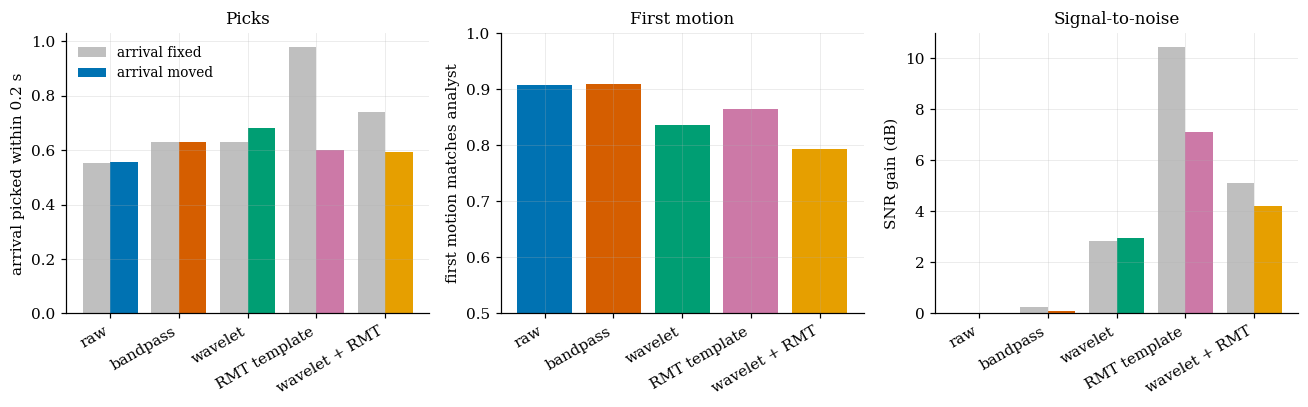

In [4]:
methods = list(centred)
colours = dict(zip(methods, figstyle.PALETTE))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

pos = np.arange(len(methods))
axes[0].bar(pos - 0.2, [centred[m]['picked_within_tolerance'] for m in methods], 0.4,
            color='0.75', label='arrival fixed')
axes[0].bar(pos + 0.2, [shifted[m]['picked_within_tolerance'] for m in methods], 0.4,
            color=[colours[m] for m in methods], label='arrival moved')
axes[0].set_ylabel('arrival picked within 0.2 s')
axes[0].set_title('Picks')
axes[0].legend(loc='upper left')

axes[1].bar(pos, [shifted[m]['polarity_correct'] for m in methods], color=[colours[m] for m in methods])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('first motion matches analyst')
axes[1].set_title('First motion')

axes[2].bar(pos - 0.2, [centred[m]['snr_gain_db'] for m in methods], 0.4, color='0.75')
axes[2].bar(pos + 0.2, [shifted[m]['snr_gain_db'] for m in methods], 0.4, color=[colours[m] for m in methods])
axes[2].set_ylabel('SNR gain (dB)')
axes[2].set_title('Signal-to-noise')

for ax in axes:
    ax.set_xticks(pos)
    ax.set_xticklabels(methods, rotation=30, ha='right')
fig.tight_layout()
figstyle.save(fig, 'figures/fig2_scoreboard')
plt.show()

**The random-matrix template's score was mostly an artefact.** With the arrival where it
always is, it picks 98% of arrivals and adds 10 dB. Move the arrival and it drops to 60% -
barely better than doing nothing (56%). Most of what it had learned was *where* arrivals
are, not what they look like.

**A cleaner waveform is not a better one.** Wavelet denoising picks the most arrivals once
they move (68%) and adds 3 dB, but flips the first motion on about one trace in fourteen -
and first motions are what fault orientations are computed from. The plain bandpass
filter is the only method that improves picks without damaging the first motion.

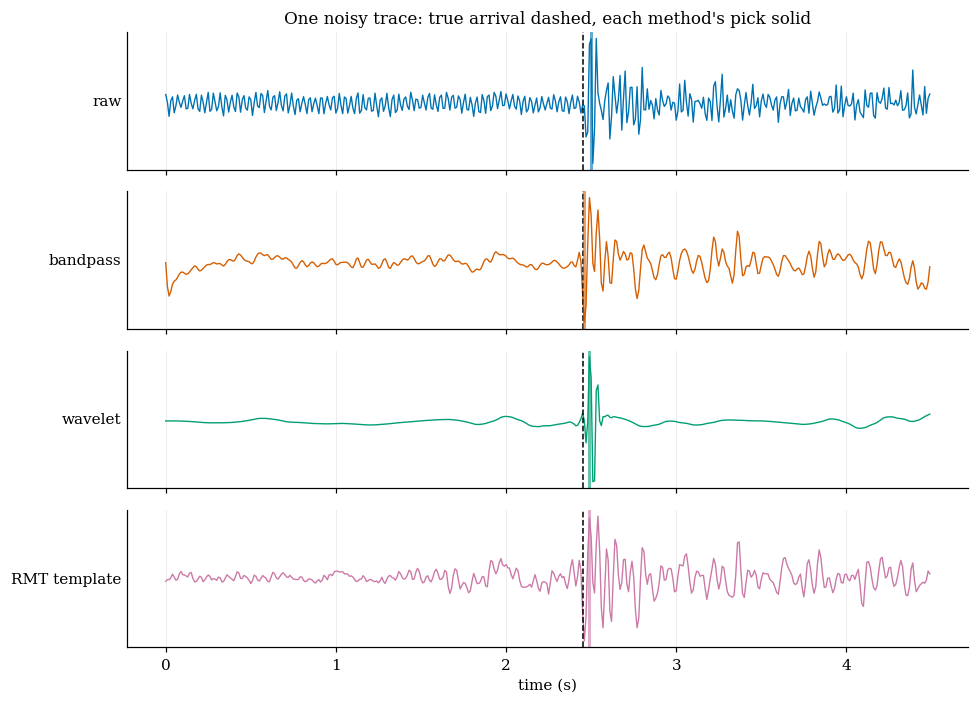

In [5]:
#one noisy trace, four treatments, with each method's pick
i = int(np.argsort(np.abs(shifted['bandpass']['errors'] - 0.0))[40])
t = np.arange(X_shift.shape[1]) / s.FS
show = ['raw', 'bandpass', 'wavelet', 'RMT template']
fig, axes = plt.subplots(len(show), 1, figsize=(9, 6.5), sharex=True)
for ax, name in zip(axes, show):
    trace = s.METHODS[name](X_shift)[i] if name != 'RMT template' else s.rmt_denoise(X_shift)[i]
    ax.plot(t, trace / np.abs(trace).max(), color=colours[name], lw=0.9)
    ax.axvline(arrivals[i] / s.FS, color='k', ls='--', lw=1)
    pick = s.sta_lta_pick(trace[None, :])[0]
    if pick >= 0:
        ax.axvline(pick / s.FS, color=colours[name], lw=2, alpha=0.6)
    ax.set_ylabel(name, rotation=0, ha='right', va='center')
    ax.set_yticks([])
axes[0].set_title('One noisy trace: true arrival dashed, each method\'s pick solid')
axes[-1].set_xlabel('time (s)')
fig.tight_layout()
figstyle.save(fig, 'figures/fig1_one_trace')
plt.show()

## Part B - a synthetic array

Sixteen to forty-eight sensors in a line. A wave crosses them with known delays; a road
runs past some of them, so their noise is **shared**, on top of each sensor's own.
Averaging cancels independent noise but not shared noise. The best weighted stack is

$$ w = \frac{\Sigma^{-1} a}{a^\top \Sigma^{-1} a}$$

- the Capon beamformer from array processing (1969), and *exactly* the minimum-variance
portfolio from finance (1952). It needs the noise covariance $\Sigma$, estimated from a
stretch of noise before the wave arrives, and judged on a different stretch.

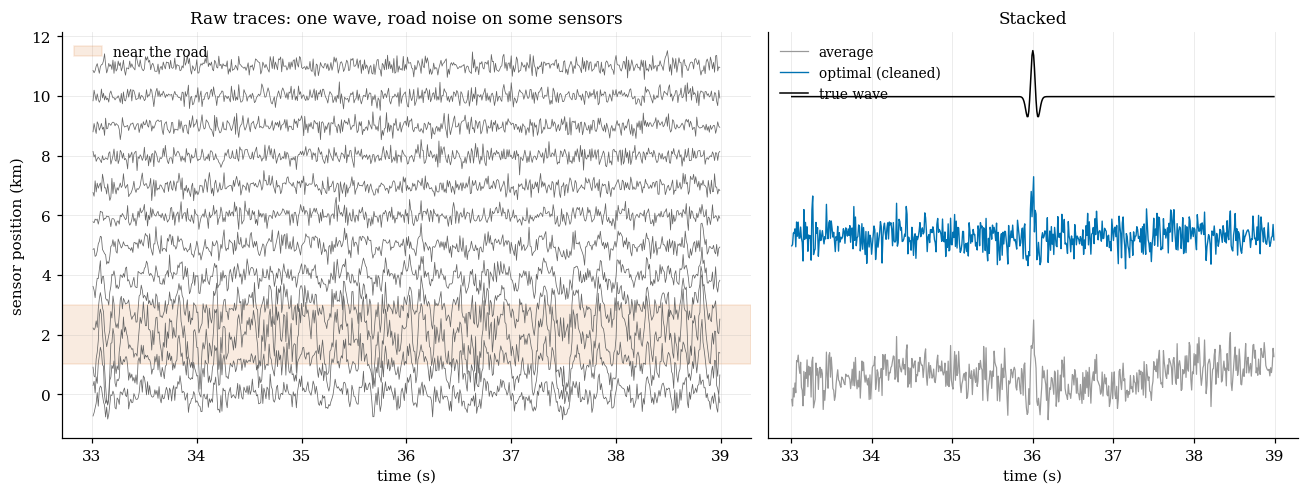

In [6]:
Xa, clean, delays, x_km, exposure = s.synthetic_array(n_sensors=24, n_samples=4200, arrival=3600,
                                                      road_strength=4.0, seed=3)
aligned = s.align_known(Xa, delays)
from corrlib import array_stacking as stack
s_avg, _ = stack.simple(aligned)
s_opt, w_opt = stack.mvdr(aligned, clean='nonlinear_shrinkage', noise_window=(1400, 1800))

t = np.arange(Xa.shape[1]) / s.FS
win = (t > 33) & (t < 39)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})
for k in range(0, 24, 2):
    axes[0].plot(t[win], Xa[k, win] / 6 + x_km[k], color='0.4', lw=0.5)
axes[0].axhspan(1.0, 3.0, color=figstyle.PALETTE[1], alpha=0.12, label='near the road')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('sensor position (km)')
axes[0].set_title('Raw traces: one wave, road noise on some sensors')
axes[0].legend(loc='upper left')

axes[1].plot(t[win], s_avg[win], color='0.6', lw=0.8, label='average')
axes[1].plot(t[win], s_opt[win] + 3, color=figstyle.PALETTE[0], lw=0.9, label='optimal (cleaned)')
axes[1].plot(t[win], s.align_known(clean, delays)[0, win] + 6, color='k', lw=1, label='true wave')
axes[1].set_yticks([])
axes[1].set_xlabel('time (s)')
axes[1].set_title('Stacked')
axes[1].legend(loc='upper left')
fig.tight_layout()
figstyle.save(fig, 'figures/fig3_array')
plt.show()

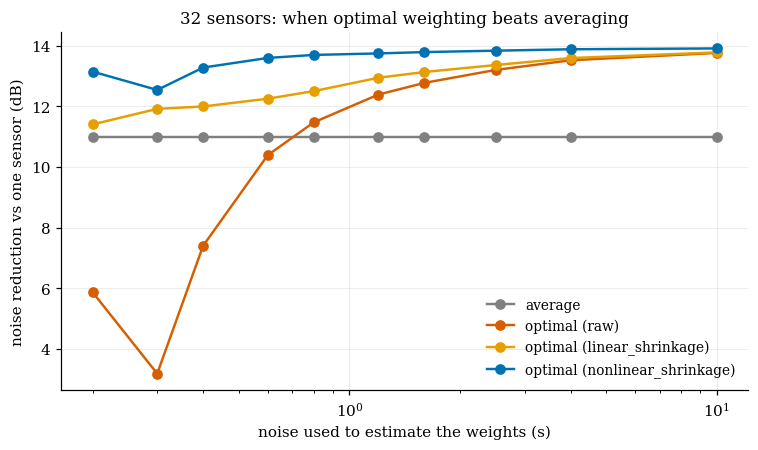

raw optimal weights beat averaging after about 0.8 s of noise; cleaned weights beat it from 0.2 s


In [7]:
#how much data does each method need? 32 sensors, training windows from 0.2 s to 10 s
train = [20, 30, 40, 60, 80, 120, 160, 250, 400, 1000]
seeds = range(8)
runs = {T: [s.stack_gains(32, T, seed=k) for k in seeds] for T in train}
labels = list(runs[train[0]][0])
mean = {lab: [np.mean([r[lab] for r in runs[T]]) for T in train] for lab in labels}

fig, ax = plt.subplots(figsize=(7, 4.2))
for lab, c in zip(labels, ['0.5', figstyle.PALETTE[1], figstyle.PALETTE[4], figstyle.PALETTE[0]]):
    ax.plot(np.array(train) / s.FS, mean[lab], 'o-', color=c, label=lab)
ax.set_xscale('log')
ax.set_xlabel('noise used to estimate the weights (s)')
ax.set_ylabel('noise reduction vs one sensor (dB)')
ax.set_title('32 sensors: when optimal weighting beats averaging')
ax.legend()
fig.tight_layout()
figstyle.save(fig, 'figures/fig4_crossover')
plt.show()

crossover = next((T for T, a, r in zip(train, mean['average'], mean['optimal (raw)']) if r > a), None)
print(f"raw optimal weights beat averaging after about {crossover / s.FS:.1f} s of noise; "
      f"cleaned weights beat it from {train[0] / s.FS:.1f} s")

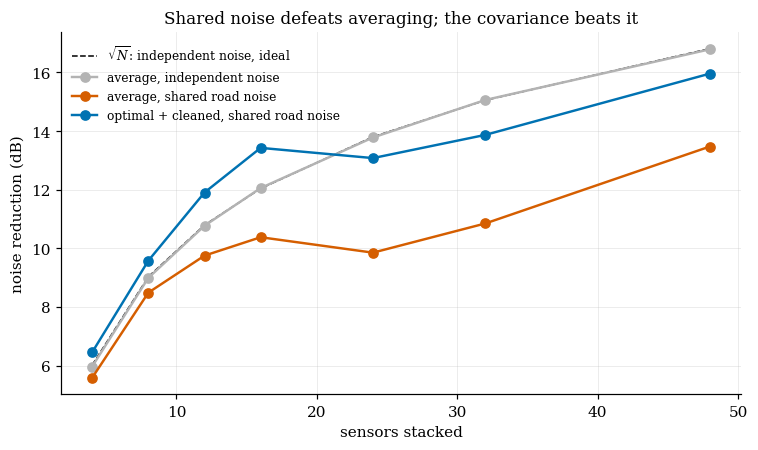

In [8]:
#and the hero: noise reduction against array size, averaging vs the optimal stack
sizes = [4, 8, 12, 16, 24, 32, 48]
g = {n: [s.stack_gains(n, 400, seed=k) for k in range(20)] for n in sizes}
g_ind = {n: [s.stack_gains(n, 400, seed=k, correlated=False) for k in range(20)] for n in sizes}

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sizes, 10 * np.log10(sizes), 'k--', lw=1, label=r'$\sqrt{N}$: independent noise, ideal')
ax.plot(sizes, [np.mean([r['average'] for r in g_ind[n]]) for n in sizes], 'o-', color='0.7',
        label='average, independent noise')
ax.plot(sizes, [np.mean([r['average'] for r in g[n]]) for n in sizes], 'o-', color=figstyle.PALETTE[1],
        label='average, shared road noise')
ax.plot(sizes, [np.mean([r['optimal (nonlinear_shrinkage)'] for r in g[n]]) for n in sizes], 'o-',
        color=figstyle.PALETTE[0], label='optimal + cleaned, shared road noise')
ax.set_xlabel('sensors stacked')
ax.set_ylabel('noise reduction (dB)')
ax.set_title('Shared noise defeats averaging; the covariance beats it')
ax.legend(fontsize=8)
fig.tight_layout()
figstyle.save(fig, 'figures/hero')
plt.show()

**Shared noise stalls averaging; the covariance recovers it.** With independent noise the
plain average tracks the $\sqrt{N}$ ideal. Put a road past some sensors and it falls
behind; the minimum-variance stack finds the road in the covariance and cancels it.

**With little data, the textbook formula loses - unless the covariance is cleaned.**
Estimated from a fraction of a second of noise, raw optimal weights do worse than plain
averaging. With the same random-matrix cleaning used for stock portfolios, they win from
the start.